In [1]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# # Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# # Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

# import kagglehub
# # kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
# ============================================================
# Cell 1 : Imports & Configuration
# ============================================================

import os
import random
import time
import copy
from pathlib import Path

import numpy as np
import pandas as pd

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import models, transforms

from torch.cuda.amp import autocast, GradScaler

from tqdm.auto import tqdm

# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# -----------------------------
# Speed Optimizations
# -----------------------------
torch.backends.cudnn.benchmark = True

# -----------------------------
# Dataset Paths
# -----------------------------
# REAL_DIR = Path(
#     "/kaggle/input/datasets/arshsefarsh/diff-group-11-dsai/Real/Real"
# )

# FAKE_DIR = Path(
#     "/kaggle/input/datasets/arshsefarsh/diff-group-11-dsai/SDv21_DS0.7/SDv21_DS0.7"
# )
REAL_DIR = Path(
    "/kaggle/input/datasets/philosopher0808/real-vs-ai-generated-faces-dataset/data_source/data_source/ffhq"
)

FAKE_DIR = Path(
    "/kaggle/input/datasets/mohannadaymansalah/stable-diffusion-dataaaaaaaaa"
)

# -----------------------------
# Training Configuration
# -----------------------------
IMG_SIZE = 224

BATCH_SIZE = 128

NUM_WORKERS = 4

EPOCHS_STAGE1 = 3
EPOCHS_STAGE2 = 7

LR_STAGE1 = 3e-4
LR_STAGE2 = 1e-5

WEIGHT_DECAY = 1e-4

MODEL_NAME = "mobilenet_v3_large"

MODEL_SAVE_PATH = "/kaggle/working/mobilenetv3_best.pth"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 60)
print("Device :", DEVICE)
print("GPU    :", torch.cuda.get_device_name(0))
print("=" * 60)

# -----------------------------
# Dataset Size
# -----------------------------
# Set to None to use ALL images.
#
# Examples:
#
# 10000 -> uses 10K Real + 10K Fake
#
# 15000 -> uses 15K Real + 15K Fake
#
# None -> uses every image
#
IMAGES_PER_CLASS = 15000

# -----------------------------
# DataLoader
# -----------------------------
PIN_MEMORY = True
PERSISTENT_WORKERS = True

# -----------------------------
# Mixed Precision
# -----------------------------
scaler = GradScaler()

print("\nConfiguration")
print("----------------------")
print(f"Image Size        : {IMG_SIZE}")
print(f"Batch Size        : {BATCH_SIZE}")
print(f"Stage 1 Epochs    : {EPOCHS_STAGE1}")
print(f"Stage 2 Epochs    : {EPOCHS_STAGE2}")
print(f"Images/Class      : {IMAGES_PER_CLASS}")
print(f"Mixed Precision   : Enabled")

Device : cuda
GPU    : Tesla T4

Configuration
----------------------
Image Size        : 224
Batch Size        : 128
Stage 1 Epochs    : 3
Stage 2 Epochs    : 7
Images/Class      : 15000
Mixed Precision   : Enabled


/tmp/ipykernel_22/897059626.py:119: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [3]:
# ============================================================
# Cell 2 : Build Dataset DataFrame
# ============================================================

VALID_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
)


def get_image_paths(folder):
    """Recursively collect all image paths."""
    paths = []

    for ext in VALID_EXTENSIONS:
        paths.extend(folder.rglob(f"*{ext}"))
        paths.extend(folder.rglob(f"*{ext.upper()}"))

    return sorted(paths)


print("Loading image paths...")

real_images = get_image_paths(REAL_DIR)
fake_images = get_image_paths(FAKE_DIR)

print(f"Found {len(real_images):,} Real images")
print(f"Found {len(fake_images):,} Fake images")


# ---------------------------------------------------
# Optional sampling
# ---------------------------------------------------
if IMAGES_PER_CLASS is not None:

    n_real = min(IMAGES_PER_CLASS, len(real_images))
    n_fake = min(IMAGES_PER_CLASS, len(fake_images))

    random.shuffle(real_images)
    random.shuffle(fake_images)

    real_images = real_images[:n_real]
    fake_images = fake_images[:n_fake]


print("\nUsing")

print(f"Real : {len(real_images):,}")
print(f"Fake : {len(fake_images):,}")


# ---------------------------------------------------
# Create DataFrame
# label:
# 0 -> Real
# 1 -> Fake
# ---------------------------------------------------

real_df = pd.DataFrame({
    "filepath": [str(p) for p in real_images],
    "label": 0
})

fake_df = pd.DataFrame({
    "filepath": [str(p) for p in fake_images],
    "label": 1
})

df = pd.concat(
    [real_df, fake_df],
    ignore_index=True
)

# Shuffle dataset
df = df.sample(
    frac=1,
    random_state=SEED
).reset_index(drop=True)

print("\nDataset Summary")
print("----------------------------")
print(df["label"].value_counts())

print("\nTotal Images :", len(df))

display(df.head())

Loading image paths...
Found 70,000 Real images
Found 9,001 Fake images

Using
Real : 15,000
Fake : 9,001

Dataset Summary
----------------------------
label
0    15000
1     9001
Name: count, dtype: int64

Total Images : 24001


,filepath,label
0,/kaggle/input/datasets/mohannadaymansalah/stab...,1
1,/kaggle/input/datasets/mohannadaymansalah/stab...,1
2,/kaggle/input/datasets/philosopher0808/real-vs...,0
3,/kaggle/input/datasets/mohannadaymansalah/stab...,1
4,/kaggle/input/datasets/philosopher0808/real-vs...,0


In [4]:
# ============================================================
# Cell 3 : Train / Validation / Test Split
# ============================================================

# First split:
# 80% Train
# 20% Temp

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label"],
    random_state=SEED,
)

# Second split:
# Temp (20%) -> Validation (10%) + Test (10%)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED,
)

print("=" * 50)
print("Dataset Split")
print("=" * 50)

print(f"Train      : {len(train_df):,}")
print(f"Validation : {len(val_df):,}")
print(f"Test        : {len(test_df):,}")

print("\nTrain Distribution")
print(train_df.label.value_counts().sort_index())

print("\nValidation Distribution")
print(val_df.label.value_counts().sort_index())

print("\nTest Distribution")
print(test_df.label.value_counts().sort_index())

# Reset indices (important for Dataset class)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

Dataset Split
Train      : 19,200
Validation : 2,400
Test        : 2,401

Train Distribution
label
0    12000
1     7200
Name: count, dtype: int64

Validation Distribution
label
0    1500
1     900
Name: count, dtype: int64

Test Distribution
label
0    1500
1     901
Name: count, dtype: int64


In [5]:
# ============================================================
# Cell 4 : Dataset, Transforms & DataLoaders
# ============================================================

# -----------------------------
# Training Transform
# -----------------------------
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        IMG_SIZE,
        scale=(0.9, 1.0)
    ),
    transforms.RandomHorizontalFlip(p=0.5),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10,
        hue=0.02
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# -----------------------------
# Validation/Test Transform
# -----------------------------
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# ============================================================
# Custom Dataset
# ============================================================

class ImageDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        img_path = self.df.iloc[idx]["filepath"]
        label = int(self.df.iloc[idx]["label"])

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label


# ============================================================
# Build Dataset Objects
# ============================================================

train_dataset = ImageDataset(
    train_df,
    transform=train_transform
)

val_dataset = ImageDataset(
    val_df,
    transform=val_transform
)

test_dataset = ImageDataset(
    test_df,
    transform=val_transform
)


# ============================================================
# DataLoaders
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS
)


print("=" * 60)
print("DataLoader Ready")
print("=" * 60)

print(f"Train Images : {len(train_dataset):,}")
print(f"Val Images   : {len(val_dataset):,}")
print(f"Test Images  : {len(test_dataset):,}")

print(f"\nTrain Batches : {len(train_loader)}")
print(f"Val Batches   : {len(val_loader)}")
print(f"Test Batches  : {len(test_loader)}")


# ------------------------------------------------------------
# Quick sanity check
# ------------------------------------------------------------

images, labels = next(iter(train_loader))

print("\nBatch Shape :", images.shape)
print("Labels Shape:", labels.shape)
print("Tensor Type :", images.dtype)

DataLoader Ready
Train Images : 19,200
Val Images   : 2,400
Test Images  : 2,401

Train Batches : 150
Val Batches   : 19
Test Batches  : 19

Batch Shape : torch.Size([128, 3, 224, 224])
Labels Shape: torch.Size([128])
Tensor Type : torch.float32


In [6]:
# ============================================================
# Cell 5 : Build MobileNetV3-Large
# ============================================================

from torchvision.models import (
    mobilenet_v3_large,
    MobileNet_V3_Large_Weights
)

# ------------------------------------------------------------
# Load ImageNet Pretrained Model
# ------------------------------------------------------------

weights = MobileNet_V3_Large_Weights.DEFAULT

model = mobilenet_v3_large(weights=weights)

print(model.classifier)

# ------------------------------------------------------------
# Freeze Entire Backbone
# ------------------------------------------------------------

for param in model.features.parameters():
    param.requires_grad = False

# ------------------------------------------------------------
# Replace Classification Head
# ------------------------------------------------------------

in_features = model.classifier[-1].in_features

model.classifier[-1] = nn.Linear(
    in_features,
    2
)

model = model.to(DEVICE)

# ------------------------------------------------------------
# Loss Function
# ------------------------------------------------------------

criterion = nn.CrossEntropyLoss()

# ------------------------------------------------------------
# Optimizer (Stage 1)
# ------------------------------------------------------------

optimizer = optim.AdamW(
    model.classifier.parameters(),
    lr=LR_STAGE1,
    weight_decay=WEIGHT_DECAY
)

# ------------------------------------------------------------
# Learning Rate Scheduler
# ------------------------------------------------------------

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS_STAGE1
)

# ------------------------------------------------------------
# Parameter Count
# ------------------------------------------------------------

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("="*60)
print("Model Ready")
print("="*60)

print(f"Total Parameters      : {total_params:,}")
print(f"Trainable Parameters  : {trainable_params:,}")

print(f"\nStage 1 Learning Rate : {LR_STAGE1}")
print(f"Optimizer             : AdamW")
print(f"Scheduler             : CosineAnnealingLR")

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 96.7MB/s]


Sequential(
  (0): Linear(in_features=960, out_features=1280, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1280, out_features=1000, bias=True)
)
Model Ready
Total Parameters      : 4,204,594
Trainable Parameters  : 1,232,642

Stage 1 Learning Rate : 0.0003
Optimizer             : AdamW
Scheduler             : CosineAnnealingLR


In [7]:
# ============================================================
# Cell 6 : Training Functions + Stage 1
# ============================================================

best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())


# ------------------------------------------------------------
# Train One Epoch
# ------------------------------------------------------------
def train_one_epoch(model, loader, optimizer, criterion):

    model.train()

    running_loss = 0.0
    running_correct = 0
    total = 0

    pbar = tqdm(loader, leave=False)

    for images, labels in pbar:

        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()

        with autocast():

            outputs = model(images)

            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        preds = outputs.argmax(dim=1)

        running_loss += loss.item() * images.size(0)
        running_correct += (preds == labels).sum().item()
        total += labels.size(0)

        pbar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total

    return epoch_loss, epoch_acc


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------
def validate(model, loader, criterion):

    model.eval()

    running_loss = 0.0
    running_correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            with autocast():

                outputs = model(images)

                loss = criterion(outputs, labels)

            preds = outputs.argmax(dim=1)

            running_loss += loss.item() * images.size(0)
            running_correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total

    return epoch_loss, epoch_acc


# ============================================================
# Stage 1 Training
# ============================================================

print("=" * 60)
print("Stage 1 : Training Classifier")
print("=" * 60)

for epoch in range(EPOCHS_STAGE1):

    start = time.time()

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion
    )

    scheduler.step()

    elapsed = time.time() - start

    print(
        f"Epoch [{epoch+1}/{EPOCHS_STAGE1}] "
        f"| Train Loss {train_loss:.4f} "
        f"| Train Acc {train_acc*100:.2f}% "
        f"| Val Loss {val_loss:.4f} "
        f"| Val Acc {val_acc*100:.2f}% "
        f"| Time {elapsed:.1f}s"
    )

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        best_model_wts = copy.deepcopy(
            model.state_dict()
        )

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_acc": val_acc,
            },
            MODEL_SAVE_PATH,
        )

        print(f"✅ Best model saved ({best_val_acc*100:.2f}%)")

print("\nStage 1 Complete")
print(f"Best Validation Accuracy : {best_val_acc*100:.2f}%")

Stage 1 : Training Classifier


  0%|          | 0/150 [00:06<?, ?it/s]

/tmp/ipykernel_22/3933303983.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_22/3933303983.py:75: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [1/3] | Train Loss 0.0709 | Train Acc 97.80% | Val Loss 0.0493 | Val Acc 98.17% | Time 192.3s
✅ Best model saved (98.17%)


  0%|          | 0/150 [00:00<?, ?it/s]

Epoch [2/3] | Train Loss 0.0162 | Train Acc 99.50% | Val Loss 0.0144 | Val Acc 99.67% | Time 152.4s
✅ Best model saved (99.67%)


  0%|          | 0/150 [00:00<?, ?it/s]

Epoch [3/3] | Train Loss 0.0099 | Train Acc 99.75% | Val Loss 0.0103 | Val Acc 99.75% | Time 154.2s
✅ Best model saved (99.75%)

Stage 1 Complete
Best Validation Accuracy : 99.75%


In [8]:
# ============================================================
# Cell 7 : Stage 2 Fine-Tuning
# ============================================================

print("=" * 60)
print("Loading Best Stage 1 Model")
print("=" * 60)

checkpoint = torch.load(
    MODEL_SAVE_PATH,
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

best_val_acc = checkpoint["val_acc"]

# ------------------------------------------------------------
# Unfreeze Last 25% of Backbone
# ------------------------------------------------------------

feature_blocks = list(model.features.children())

num_blocks = len(feature_blocks)
start_block = int(num_blocks * 0.75)

print(f"Total Feature Blocks : {num_blocks}")
print(f"Unfreezing Blocks    : {start_block} → {num_blocks-1}")

for block in feature_blocks[start_block:]:

    for param in block.parameters():
        param.requires_grad = True

# ------------------------------------------------------------
# Show Trainable Parameters
# ------------------------------------------------------------

trainable = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

total = sum(
    p.numel()
    for p in model.parameters()
)

print(f"\nTrainable Parameters : {trainable:,}")
print(f"Total Parameters     : {total:,}")

# ------------------------------------------------------------
# Optimizer
# ------------------------------------------------------------

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_STAGE2,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS_STAGE2
)

# ============================================================
# Stage 2 Training
# ============================================================

print("\n")
print("=" * 60)
print("Stage 2 : Fine-Tuning")
print("=" * 60)

for epoch in range(EPOCHS_STAGE2):

    start = time.time()

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion
    )

    scheduler.step()

    elapsed = time.time() - start

    print(
        f"Epoch [{epoch+1}/{EPOCHS_STAGE2}] "
        f"| Train Loss {train_loss:.4f} "
        f"| Train Acc {train_acc*100:.2f}% "
        f"| Val Loss {val_loss:.4f} "
        f"| Val Acc {val_acc*100:.2f}% "
        f"| Time {elapsed:.1f}s"
    )

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            {
                "epoch": EPOCHS_STAGE1 + epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_acc": val_acc,
            },
            MODEL_SAVE_PATH,
        )

        print(f"✅ New Best Model Saved ({best_val_acc*100:.2f}%)")

print("\n")
print("=" * 60)
print("Training Finished")
print("=" * 60)

print(f"Best Validation Accuracy : {best_val_acc*100:.2f}%")

Loading Best Stage 1 Model
Total Feature Blocks : 17
Unfreezing Blocks    : 12 → 16

Trainable Parameters : 3,798,226
Total Parameters     : 4,204,594


Stage 2 : Fine-Tuning


  0%|          | 0/150 [00:00<?, ?it/s]

/tmp/ipykernel_22/3933303983.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_22/3933303983.py:75: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [1/7] | Train Loss 0.0079 | Train Acc 99.77% | Val Loss 0.0066 | Val Acc 99.79% | Time 161.3s
✅ New Best Model Saved (99.79%)


  0%|          | 0/150 [00:00<?, ?it/s]

...

Epoch [5/7] | Train Loss 0.0014 | Train Acc 99.98% | Val Loss 0.0038 | Val Acc 99.88% | Time 158.2s


  0%|          | 0/150 [00:00<?, ?it/s]

Epoch [6/7] | Train Loss 0.0017 | Train Acc 99.95% | Val Loss 0.0037 | Val Acc 99.88% | Time 155.6s


  0%|          | 0/150 [00:00<?, ?it/s]

Epoch [7/7] | Train Loss 0.0011 | Train Acc 99.99% | Val Loss 0.0038 | Val Acc 99.88% | Time 161.3s


Training Finished
Best Validation Accuracy : 99.88%


Loaded Best Model
Validation Accuracy : 99.88%


  0%|          | 0/19 [00:00<?, ?it/s]

/tmp/ipykernel_22/234285206.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():




Test Results
Test Loss     : 0.0011
Test Accuracy : 99.96%

Classification Report

              precision    recall  f1-score   support

        Real     1.0000    0.9993    0.9997      1500
        Fake     0.9989    1.0000    0.9994       901

    accuracy                         0.9996      2401
   macro avg     0.9994    0.9997    0.9996      2401
weighted avg     0.9996    0.9996    0.9996      2401


Confusion Matrix
[[1499    1]
 [   0  901]]


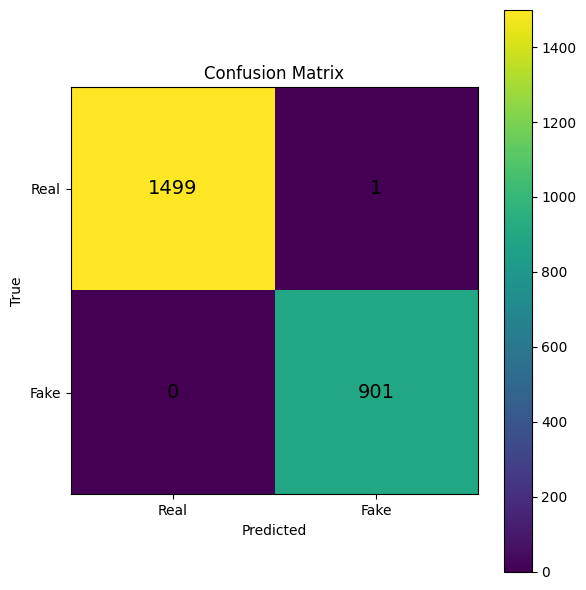

In [9]:
# ============================================================
# Cell 8 : Final Evaluation
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Load Best Model
# ------------------------------------------------------------

checkpoint = torch.load(
    MODEL_SAVE_PATH,
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("="*60)
print("Loaded Best Model")
print("="*60)

print(f"Validation Accuracy : {checkpoint['val_acc']*100:.2f}%")

# ------------------------------------------------------------
# Test Evaluation
# ------------------------------------------------------------

test_loss = 0.0
correct = 0
total = 0

all_labels = []
all_preds = []

with torch.no_grad():

    pbar = tqdm(test_loader)

    for images, labels in pbar:

        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        with autocast():

            outputs = model(images)

            loss = criterion(outputs, labels)

        preds = outputs.argmax(dim=1)

        test_loss += loss.item() * images.size(0)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_preds.extend(
            preds.cpu().numpy()
        )

test_loss /= total
test_acc = correct / total

print("\n")
print("="*60)
print("Test Results")
print("="*60)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc*100:.2f}%")

# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------

print("\nClassification Report\n")

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=["Real", "Fake"],
        digits=4
    )
)

# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    all_labels,
    all_preds
)

print("\nConfusion Matrix")

print(cm)

# ------------------------------------------------------------
# Plot Confusion Matrix
# ------------------------------------------------------------

plt.figure(figsize=(6,6))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

plt.xticks(
    [0,1],
    ["Real","Fake"]
)

plt.yticks(
    [0,1],
    ["Real","Fake"]
)

for i in range(2):
    for j in range(2):

        plt.text(
            j,
            i,
            cm[i,j],
            ha="center",
            va="center",
            fontsize=14
        )

plt.xlabel("Predicted")
plt.ylabel("True")

plt.tight_layout()

plt.show()

✅ Model Loaded Successfully


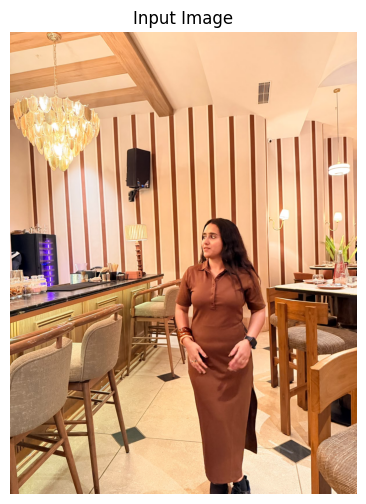

Prediction
Predicted Class : Real

Real Probability         : 95.71%
AI Generated Probability : 4.29%
Confidence : 95.71%


In [10]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import transforms
from torchvision.models import mobilenet_v3_large

# ============================================================
# Configuration
# ============================================================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL_PATH = "/kaggle/working/mobilenetv3_best.pth"

IMAGE_PATH = "/kaggle/input/datasets/arshsefarsh/testing/testing/real/vishaka-teammate.jpeg"

CLASS_NAMES = [
    "Real",
    "AI Generated"
]

# ============================================================
# Build Model
# ============================================================

model = mobilenet_v3_large(weights=None)

in_features = model.classifier[-1].in_features
model.classifier[-1] = nn.Linear(in_features, 2)

checkpoint = torch.load(
    MODEL_PATH,
    map_location=DEVICE
)

model.load_state_dict(checkpoint["model_state_dict"])

model.to(DEVICE)
model.eval()

print("✅ Model Loaded Successfully")

# ============================================================
# Image Transform
# ============================================================

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ============================================================
# Load Image
# ============================================================

image = Image.open(IMAGE_PATH).convert("RGB")

# Display uploaded image
plt.figure(figsize=(6,6))
plt.imshow(image)
plt.title("Input Image")
plt.axis("off")
plt.show()

# ============================================================
# Prediction
# ============================================================

input_tensor = transform(image).unsqueeze(0).to(DEVICE)

with torch.no_grad():

    logits = model(input_tensor)

    probabilities = torch.softmax(logits, dim=1)[0]

prediction = torch.argmax(probabilities).item()

real_prob = probabilities[0].item() * 100
fake_prob = probabilities[1].item() * 100

print("=" * 50)
print("Prediction")
print("=" * 50)

print(f"Predicted Class : {CLASS_NAMES[prediction]}")
print()

print(f"Real Probability         : {real_prob:.2f}%")
print(f"AI Generated Probability : {fake_prob:.2f}%")

print("=" * 50)

confidence = probabilities[prediction].item() * 100

print(f"Confidence : {confidence:.2f}%")